# Finetune Embeddings For Niche Query

#### Concat scGPT + QueST

In [4]:
# load data
import numpy as np
import pandas as pd
import scanpy as sc
import torch
import os


def load_emb(adata_folder, emb_folder, emb_key, suffix="pt", update_anndata=True):
    adata_list = []
    fnames = [fname for fname in os.listdir(adata_folder)]
    fnames.sort()
    for fname in fnames:
        if not fname.endswith(".h5ad"):
            continue
        stem = fname.replace(".h5ad", "")
        adata_path = os.path.join(adata_folder, fname)
        adata = sc.read_h5ad(adata_path)

        emb_path = os.path.join(emb_folder, f"{stem}.{suffix}")
        if not os.path.exists(emb_path):
            print(f"[SKIP] No embedding for {fname}")
            continue
        print(f"[LOAD] {emb_path}")
        if suffix == "csv":
            emb = pd.read_csv(emb_path, index_col=0).values.astype(np.float64)
        elif suffix == "pt":
            emb_tensor = torch.load(emb_path, map_location="cpu")
            emb = emb_tensor.detach().cpu().numpy()
        else:
            raise ValueError(f"Unknown suffix {suffix}")

        # -------- sanity checks --------
        if emb.ndim != 2:
            raise ValueError(f"{emb_path} embedding must be 2D, got {emb.shape}")
        if emb.shape[0] != adata.n_obs:
            raise ValueError(
                f"Cell number mismatch for {stem}: "
                f"embedding {emb.shape[0]} vs adata {adata.n_obs}"
            )

        adata.obsm[emb_key] = emb
        adata_list.append(adata)
        if update_anndata:
            adata.write_h5ad(adata_path)
        print(f"[DONE] {stem}")
    return adata_list


adata_folder = "data/"
emb_folder = "data/concat_fm_emb_scgpt"
embedding_key = "concat_scgpt_quest_emb"
adata_list = load_emb(adata_folder, emb_folder, emb_key=embedding_key, suffix="pt")

[LOAD] data/concat_fm_emb_scgpt/151507.pt
[DONE] 151507
[LOAD] data/concat_fm_emb_scgpt/151508.pt
[DONE] 151508
[LOAD] data/concat_fm_emb_scgpt/151509.pt
[DONE] 151509
[LOAD] data/concat_fm_emb_scgpt/151510.pt
[DONE] 151510
[LOAD] data/concat_fm_emb_scgpt/151669.pt
[DONE] 151669
[LOAD] data/concat_fm_emb_scgpt/151670.pt
[DONE] 151670
[LOAD] data/concat_fm_emb_scgpt/151671.pt
[DONE] 151671
[LOAD] data/concat_fm_emb_scgpt/151672.pt
[DONE] 151672
[LOAD] data/concat_fm_emb_scgpt/151673.pt
[DONE] 151673
[LOAD] data/concat_fm_emb_scgpt/151674.pt
[DONE] 151674
[LOAD] data/concat_fm_emb_scgpt/151675.pt
[DONE] 151675
[LOAD] data/concat_fm_emb_scgpt/151676.pt
[DONE] 151676


/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_6296/4132265828.py:7: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_list[0], color=f"{query_niche_id}_layer", spot_size=5, show=False,


[<Axes: title={'center': '151507'}, xlabel='spatial1', ylabel='spatial2'>]

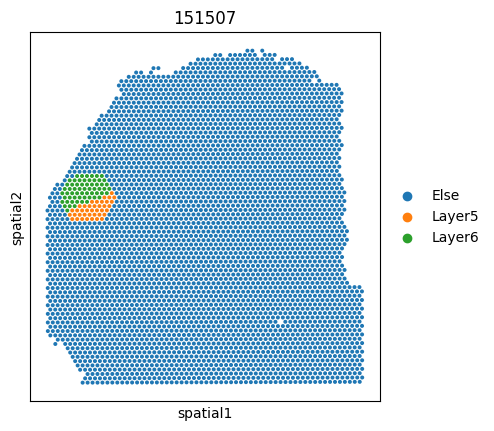

In [5]:
import scanpy as sc

# step 0: visualize query niche
query_sample_id = adata_list[0].uns["library_id"]
query_niche_id = "Layer5_Layer6_100_replicate=0"
query_niche_mask = adata_list[0].obs[f"{query_niche_id}_niche"] == "Niche"
sc.pl.spatial(
    adata_list[0],
    color=f"{query_niche_id}_layer",
    spot_size=5,
    show=False,
    title=f"{adata_list[0].uns['library_id']}",
)

[START] start processing adata: 151507
[DONE] finish adata: 151507
[START] start processing adata: 151508
[DONE] finish adata: 151508
[START] start processing adata: 151509
[DONE] finish adata: 151509
[START] start processing adata: 151510
[DONE] finish adata: 151510
[START] start processing adata: 151669
[DONE] finish adata: 151669
[START] start processing adata: 151670
[DONE] finish adata: 151670
[START] start processing adata: 151671
[DONE] finish adata: 151671
[START] start processing adata: 151672
[DONE] finish adata: 151672
[START] start processing adata: 151673
[DONE] finish adata: 151673
[START] start processing adata: 151674
[DONE] finish adata: 151674
[START] start processing adata: 151675
[DONE] finish adata: 151675
[START] start processing adata: 151676
[DONE] finish adata: 151676


/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_6296/127642276.py:23: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=f"{query_result_key}", ax=axes[i], show=False, spot_size=5,
/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_6296/127642276.py:23: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=f"{query_result_key}", ax=axes[i], show=False, spot_size=5,
/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_6296/127642276.py:23: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=f"{query_result_key}", ax=axes[i], show=False, spot_size=5,
/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_6296/127642276.py:23: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=f"{query_result_key}", ax=axes[i], show=False, spot_size=5,
/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_6296/127642276.py:23: FutureWarni

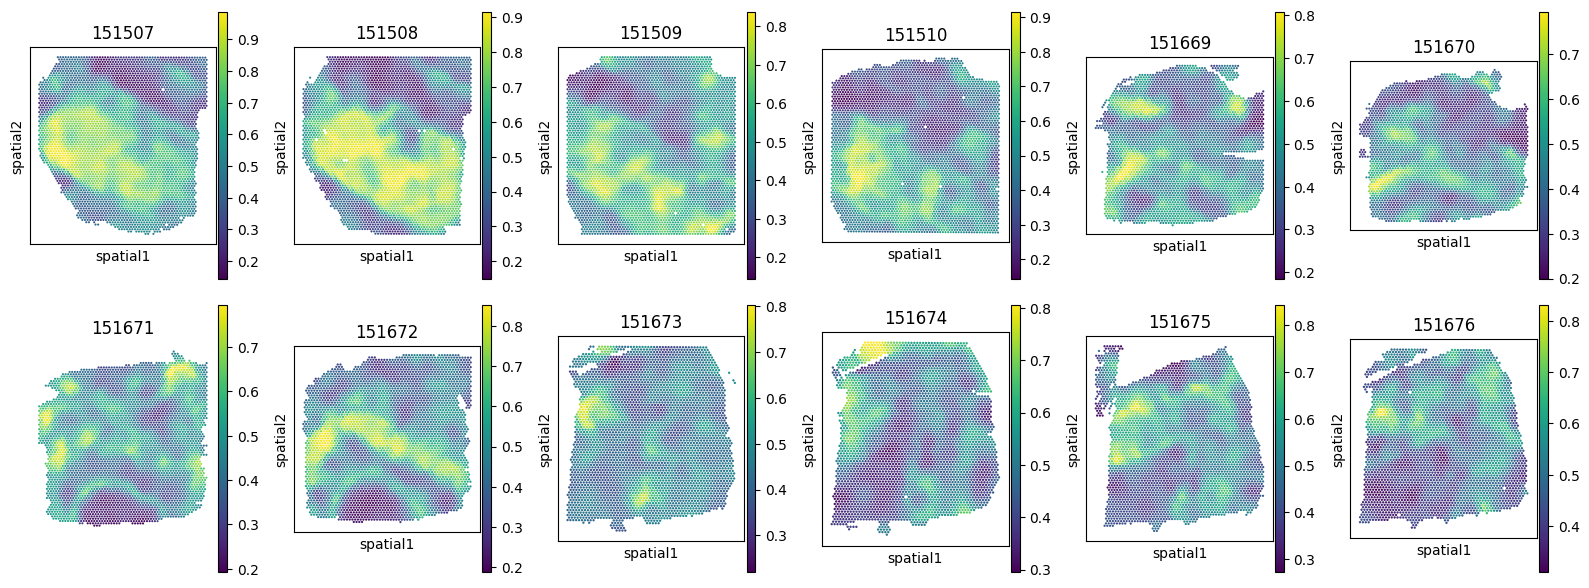

In [6]:
# niche query
from src.niche_query import NicheQuery
import matplotlib.pyplot as plt

from src.niche_emb_generator import NicheEmbGenerator

niche_embedding_key = f"{embedding_key}_niche_embedding"
niche_emb_generator = NicheEmbGenerator()
niche_embedding = niche_emb_generator.generate_niche_embedding(
    mask=query_niche_mask, embedding_key=embedding_key, adata=adata_list[0]
)
niche_emb_generator.generate_niche_embeddings(
    niche_embedding_key=niche_embedding_key,
    embedding_key=embedding_key,
    coordinates_key="spatial",
    k=3,
    adata_list=adata_list,
)

query_result_key = f"{embedding_key}_query_result"
niche_query = NicheQuery()
adata_list = niche_query.query(
    adata_list, niche_embedding, query_result_key, niche_embedding_key
)

# visualize output
fig, axes = plt.subplots(ncols=6, nrows=2, figsize=(16, 6))
axes = axes.flatten()
for i, adata in enumerate(adata_list):
    sc.pl.spatial(
        adata,
        color=f"{query_result_key}",
        ax=axes[i],
        show=False,
        spot_size=5,
        title=f"{adata.uns['library_id']}",
    )
    axes[i].invert_yaxis()
axes[6].axis("off")
fig.tight_layout()
fig.show()

#### scGPT as an input to QueST

In [8]:
# load data
import numpy as np
import pandas as pd
import torch


def load_emb(adata_folder, emb_folder, emb_key, suffix="pt", update_anndata=True):
    adata_list = []
    fnames = [fname for fname in os.listdir(adata_folder)]
    fnames.sort()
    for fname in fnames:
        if not fname.endswith(".h5ad"):
            continue
        stem = fname.replace(".h5ad", "")
        adata_path = os.path.join(adata_folder, fname)
        adata = sc.read_h5ad(adata_path)

        emb_path = os.path.join(emb_folder, f"{stem}.{suffix}")
        if not os.path.exists(emb_path):
            print(f"[SKIP] No embedding for {fname}")
            continue
        print(f"[LOAD] {emb_path}")
        if suffix == "csv":
            emb = pd.read_csv(emb_path, index_col=0).values.astype(np.float64)
        elif suffix == "pt":
            emb_tensor = torch.load(emb_path, map_location="cpu")
            emb = emb_tensor.detach().cpu().numpy()
        else:
            raise ValueError(f"Unknown suffix {suffix}")

        # -------- sanity checks --------
        if emb.ndim != 2:
            raise ValueError(f"{emb_path} embedding must be 2D, got {emb.shape}")
        if emb.shape[0] != adata.n_obs:
            raise ValueError(
                f"Cell number mismatch for {stem}: "
                f"embedding {emb.shape[0]} vs adata {adata.n_obs}"
            )

        adata.obsm[emb_key] = emb
        adata_list.append(adata)
        if update_anndata:
            adata.write_h5ad(adata_path)
        print(f"[DONE] {stem}")
    return adata_list


adata_folder = "data/"
emb_folder = "data/quest_scgpt"
embedding_key = "quest_scgpt_emb"
adata_list = load_emb(adata_folder, emb_folder, emb_key=embedding_key, suffix="pt")

[LOAD] data/quest_scgpt/151507.pt
[DONE] 151507
[LOAD] data/quest_scgpt/151508.pt
[DONE] 151508
[LOAD] data/quest_scgpt/151509.pt
[DONE] 151509
[LOAD] data/quest_scgpt/151510.pt
[DONE] 151510
[LOAD] data/quest_scgpt/151669.pt
[DONE] 151669
[LOAD] data/quest_scgpt/151670.pt
[DONE] 151670
[LOAD] data/quest_scgpt/151671.pt
[DONE] 151671
[LOAD] data/quest_scgpt/151672.pt
[DONE] 151672
[LOAD] data/quest_scgpt/151673.pt
[DONE] 151673
[LOAD] data/quest_scgpt/151674.pt
[DONE] 151674
[LOAD] data/quest_scgpt/151675.pt
[DONE] 151675
[LOAD] data/quest_scgpt/151676.pt
[DONE] 151676


/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_6296/4132265828.py:7: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_list[0], color=f"{query_niche_id}_layer", spot_size=5, show=False,


[<Axes: title={'center': '151507'}, xlabel='spatial1', ylabel='spatial2'>]

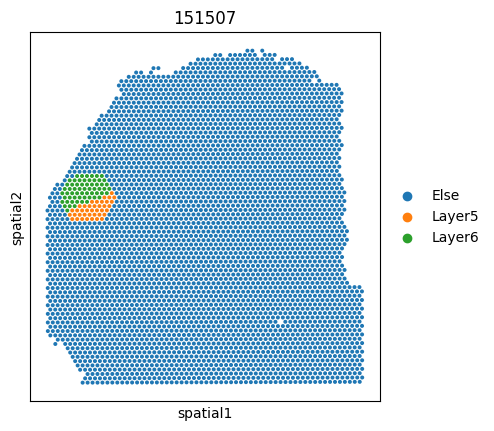

In [9]:
import scanpy as sc

# step 0: visualize query niche
query_sample_id = adata_list[0].uns["library_id"]
query_niche_id = "Layer5_Layer6_100_replicate=0"
query_niche_mask = adata_list[0].obs[f"{query_niche_id}_niche"] == "Niche"
sc.pl.spatial(
    adata_list[0],
    color=f"{query_niche_id}_layer",
    spot_size=5,
    show=False,
    title=f"{adata_list[0].uns['library_id']}",
)

In [10]:
# niche query
from src.niche_emb_generator import NicheEmbGenerator

niche_embedding_key = f"{embedding_key}_niche_embedding"
niche_emb_generator = NicheEmbGenerator()
niche_embedding = niche_emb_generator.generate_niche_embedding(
    mask=query_niche_mask, embedding_key=embedding_key, adata=adata_list[0]
)
niche_emb_generator.generate_niche_embeddings(
    niche_embedding_key=niche_embedding_key,
    embedding_key=embedding_key,
    coordinates_key="spatial",
    k=3,
    adata_list=adata_list,
)

[START] start processing adata: 151507
[DONE] finish adata: 151507
[START] start processing adata: 151508
[DONE] finish adata: 151508
[START] start processing adata: 151509
[DONE] finish adata: 151509
[START] start processing adata: 151510
[DONE] finish adata: 151510
[START] start processing adata: 151669
[DONE] finish adata: 151669
[START] start processing adata: 151670
[DONE] finish adata: 151670
[START] start processing adata: 151671
[DONE] finish adata: 151671
[START] start processing adata: 151672
[DONE] finish adata: 151672
[START] start processing adata: 151673
[DONE] finish adata: 151673
[START] start processing adata: 151674
[DONE] finish adata: 151674
[START] start processing adata: 151675
[DONE] finish adata: 151675
[START] start processing adata: 151676
[DONE] finish adata: 151676


/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_6296/1078540035.py:12: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=f"{query_result_key}", ax=axes[i], show=False, spot_size=5,
/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_6296/1078540035.py:12: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=f"{query_result_key}", ax=axes[i], show=False, spot_size=5,
/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_6296/1078540035.py:12: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=f"{query_result_key}", ax=axes[i], show=False, spot_size=5,
/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_6296/1078540035.py:12: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=f"{query_result_key}", ax=axes[i], show=False, spot_size=5,
/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_6296/1078540035.py:12: Future

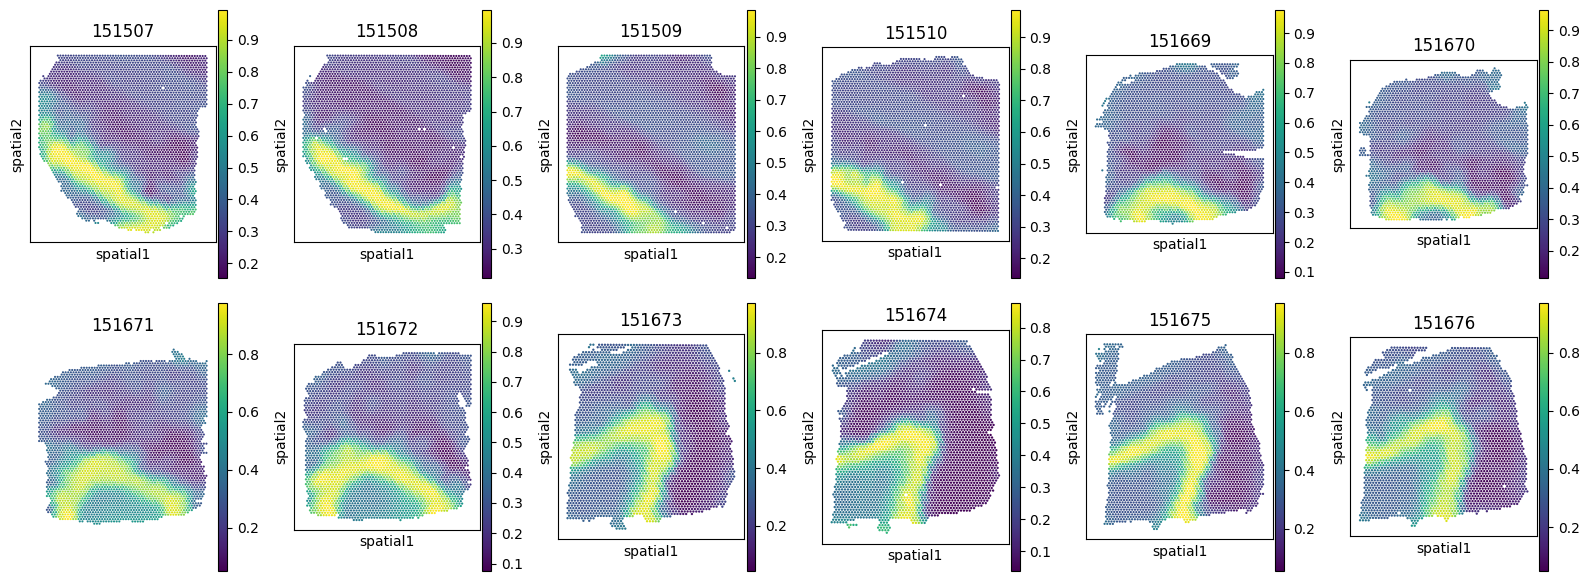

In [11]:
from src.niche_query import NicheQuery
import matplotlib.pyplot as plt

query_result_key = f"{embedding_key}_query_result"
niche_query = NicheQuery()
adata_list = niche_query.query(
    adata_list, niche_embedding, query_result_key, niche_embedding_key
)

# visualize output
fig, axes = plt.subplots(ncols=6, nrows=2, figsize=(16, 6))
axes = axes.flatten()
for i, adata in enumerate(adata_list):
    sc.pl.spatial(
        adata,
        color=f"{query_result_key}",
        ax=axes[i],
        show=False,
        spot_size=5,
        title=f"{adata.uns['library_id']}",
    )
    axes[i].invert_yaxis()
axes[6].axis("off")
fig.tight_layout()
fig.show()

#### SToFM + QueST

In [8]:
# load data


def load_stofm_emb(adata_folder, emb_folder, emb_key, update_anndata=True):
    adata_list = []
    for fname in os.listdir(adata_folder):
        if not fname.endswith(".h5ad"):
            continue
        stem = fname.replace(".h5ad", "")
        adata_path = os.path.join(adata_folder, fname)
        adata = sc.read_h5ad(adata_path)

        emb_path = os.path.join(emb_folder, f"{stem}.pt")
        if not os.path.exists(emb_path):
            print(f"[SKIP] No embedding for {fname}")
            continue
        print(f"[LOAD] {emb_path}")
        emb_tensor = torch.load(emb_path, map_location="cpu")
        emb = emb_tensor.detach().cpu().numpy()

        # -------- sanity checks --------
        if emb.ndim != 2:
            raise ValueError(f"{emb_path} embedding must be 2D, got {emb.shape}")
        if emb.shape[0] != adata.n_obs:
            raise ValueError(
                f"Cell number mismatch for {stem}: "
                f"embedding {emb.shape[0]} vs adata {adata.n_obs}"
            )

        adata.obsm[emb_key] = emb
        adata_list.append(adata)
        if update_anndata:
            adata.write_h5ad(adata_path)
        print(f"[DONE] {stem}")
    return adata_list


adata_folder = "data/"
emb_folder = "data/quest_stofm"
adata_list = load_stofm_emb(
    adata_folder, emb_folder, emb_key="stofm_quest_embedding_v1"
)

[LOAD] data/quest_stofm/151675.pt
[DONE] 151675
[LOAD] data/quest_stofm/151507.pt
[DONE] 151507
[LOAD] data/quest_stofm/151510.pt
[DONE] 151510
[LOAD] data/quest_stofm/151674.pt
[DONE] 151674
[LOAD] data/quest_stofm/151669.pt
[DONE] 151669
[LOAD] data/quest_stofm/151673.pt
[DONE] 151673
[LOAD] data/quest_stofm/151672.pt
[DONE] 151672
[LOAD] data/quest_stofm/151671.pt
[DONE] 151671
[LOAD] data/quest_stofm/151670.pt
[DONE] 151670
[LOAD] data/quest_stofm/151509.pt
[DONE] 151509
[LOAD] data/quest_stofm/151676.pt
[DONE] 151676
[LOAD] data/quest_stofm/151508.pt
[DONE] 151508


[<Axes: title={'center': '151675'}, xlabel='spatial1', ylabel='spatial2'>]

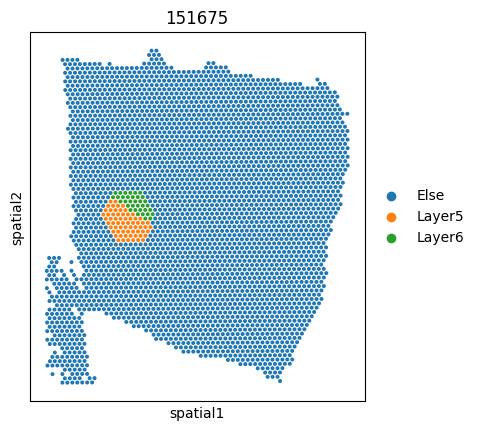

In [9]:
import scanpy as sc

# step 0: visualize query niche
query_sample_id = adata_list[0].uns["library_id"]
query_niche_id = "Layer5_Layer6_100_replicate=0"
query_niche_mask = adata_list[0].obs[f"{query_niche_id}_niche"] == "Niche"
sc.pl.spatial(
    adata_list[0],
    color=f"{query_niche_id}_layer",
    spot_size=5,
    show=False,
    title=f"{adata_list[0].uns['library_id']}",
)

In [10]:
# niche query
from src.niche_emb_generator import NicheEmbGenerator

embedding_key = "stofm_quest_embedding_v1"
niche_embedding_key = "stofm_quest_niche_embedding"
niche_emb_generator = NicheEmbGenerator()
niche_embedding = niche_emb_generator.generate_niche_embedding(
    mask=query_niche_mask, embedding_key=embedding_key, adata=adata_list[0]
)
niche_emb_generator.generate_niche_embeddings(
    niche_embedding_key=niche_embedding_key,
    embedding_key=embedding_key,
    coordinates_key="spatial",
    k=3,
    adata_list=adata_list,
)

[START] start processing adata: 151675
[DONE] finish adata: 151675
[START] start processing adata: 151507
[DONE] finish adata: 151507
[START] start processing adata: 151510
[DONE] finish adata: 151510
[START] start processing adata: 151674
[DONE] finish adata: 151674
[START] start processing adata: 151669
[DONE] finish adata: 151669
[START] start processing adata: 151673
[DONE] finish adata: 151673
[START] start processing adata: 151672
[DONE] finish adata: 151672
[START] start processing adata: 151671
[DONE] finish adata: 151671
[START] start processing adata: 151670
[DONE] finish adata: 151670
[START] start processing adata: 151509
[DONE] finish adata: 151509
[START] start processing adata: 151676
[DONE] finish adata: 151676
[START] start processing adata: 151508
[DONE] finish adata: 151508


/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_22265/3082282725.py:17: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


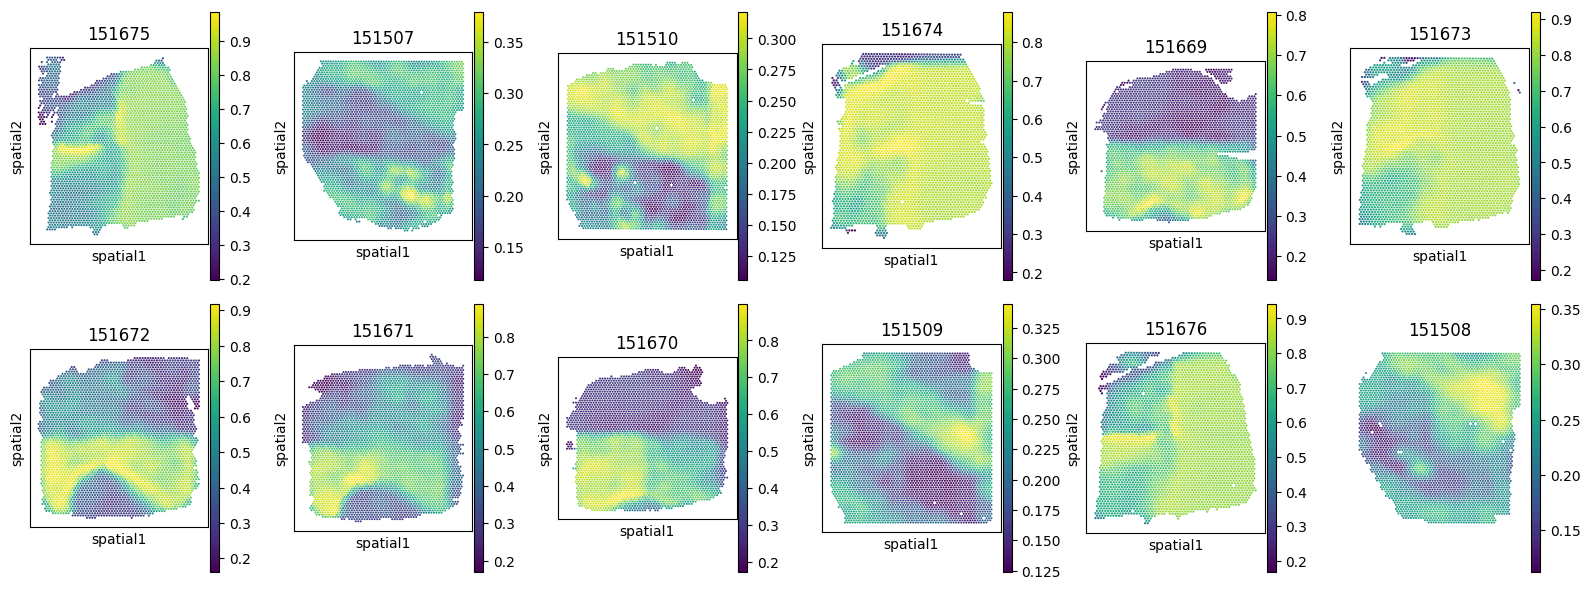

In [11]:
from src.niche_query import NicheQuery
import matplotlib.pyplot as plt

query_result_key = f"{query_niche_id}_query_result_v1"
niche_query = NicheQuery()
adata_list = niche_query.query(
    adata_list, niche_embedding, query_result_key, niche_embedding_key
)

# visualize output
fig, axes = plt.subplots(ncols=6, nrows=2, figsize=(16, 6))
axes = axes.flatten()
for i, adata in enumerate(adata_list):
    sc.pl.spatial(
        adata,
        color=f"{query_result_key}",
        ax=axes[i],
        show=False,
        spot_size=5,
        title=f"{adata.uns['library_id']}",
    )
    axes[i].invert_yaxis()
axes[11].axis("off")
fig.tight_layout()
fig.show()

#### SToFM + QueST (skip GAE)

In [8]:
# load data
import os
import torch


def load_stofm_emb(adata_folder, emb_folder, emb_key):
    adata_list = []
    for fname in os.listdir(adata_folder):
        if not fname.endswith(".h5ad"):
            continue
        stem = fname.replace(".h5ad", "")
        adata_path = os.path.join(adata_folder, fname)
        adata = sc.read_h5ad(adata_path)

        emb_path = os.path.join(emb_folder, f"{stem}.pt")
        if not os.path.exists(emb_path):
            print(f"[SKIP] No embedding for {fname}")
            continue
        print(f"[LOAD] {emb_path}")
        emb_tensor = torch.load(emb_path, map_location="cpu")
        emb = emb_tensor.detach().cpu().numpy()

        # -------- sanity checks --------
        if emb.ndim != 2:
            raise ValueError(f"{emb_path} embedding must be 2D, got {emb.shape}")
        if emb.shape[0] != adata.n_obs:
            raise ValueError(
                f"Cell number mismatch for {stem}: "
                f"embedding {emb.shape[0]} vs adata {adata.n_obs}"
            )

        adata.obsm[emb_key] = emb
        adata_list.append(adata)
        adata.write_h5ad(adata_path)
        print(f"[DONE] {stem}")
    return adata_list


adata_folder = "data/"
emb_folder = "data/SToFM_QueST"
adata_list = load_stofm_emb(adata_folder, emb_folder, emb_key="stofm_quest_embedding")

[LOAD] data/SToFM_QueST/151675.pt
[DONE] 151675
[LOAD] data/SToFM_QueST/151507.pt
[DONE] 151507
[LOAD] data/SToFM_QueST/151510.pt
[DONE] 151510
[LOAD] data/SToFM_QueST/151674.pt
[DONE] 151674
[LOAD] data/SToFM_QueST/151669.pt
[DONE] 151669
[LOAD] data/SToFM_QueST/151673.pt
[DONE] 151673
[LOAD] data/SToFM_QueST/151672.pt
[DONE] 151672
[LOAD] data/SToFM_QueST/151671.pt
[DONE] 151671
[LOAD] data/SToFM_QueST/151670.pt
[DONE] 151670
[LOAD] data/SToFM_QueST/151509.pt
[DONE] 151509
[LOAD] data/SToFM_QueST/151676.pt
[DONE] 151676
[LOAD] data/SToFM_QueST/151508.pt
[DONE] 151508


[<Axes: title={'center': '151675'}, xlabel='spatial1', ylabel='spatial2'>]

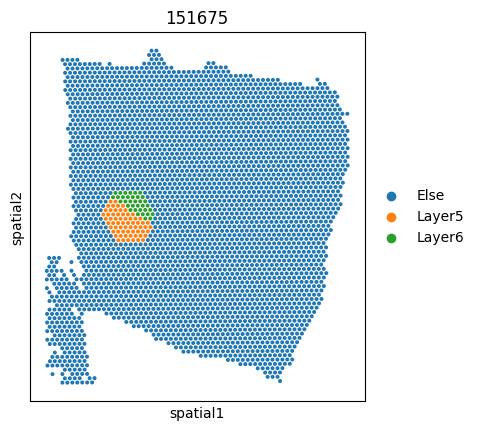

In [9]:
import scanpy as sc

# step 0: visualize query niche
query_sample_id = adata_list[0].uns["library_id"]
query_niche_id = "Layer5_Layer6_100_replicate=0"
query_niche_mask = adata_list[0].obs[f"{query_niche_id}_niche"] == "Niche"
sc.pl.spatial(
    adata_list[0],
    color=f"{query_niche_id}_layer",
    spot_size=5,
    show=False,
    title=f"{adata_list[0].uns['library_id']}",
)

In [10]:
# niche query
from src.niche_emb_generator import NicheEmbGenerator

stofm_embedding_key = "stofm_quest_embedding"
niche_embedding_key = "stofm_quest_niche_embedding"
niche_emb_generator = NicheEmbGenerator()
niche_embedding = niche_emb_generator.generate_niche_embedding(
    mask=query_niche_mask, embedding_key=stofm_embedding_key, adata=adata_list[0]
)
niche_emb_generator.generate_niche_embeddings(
    niche_embedding_key=niche_embedding_key,
    embedding_key=stofm_embedding_key,
    coordinates_key="spatial",
    k=3,
    adata_list=adata_list,
)

[START] start processing adata: 151675
[DONE] finish adata: 151675
[START] start processing adata: 151507
[DONE] finish adata: 151507
[START] start processing adata: 151510
[DONE] finish adata: 151510
[START] start processing adata: 151674
[DONE] finish adata: 151674
[START] start processing adata: 151669
[DONE] finish adata: 151669
[START] start processing adata: 151673
[DONE] finish adata: 151673
[START] start processing adata: 151672
[DONE] finish adata: 151672
[START] start processing adata: 151671
[DONE] finish adata: 151671
[START] start processing adata: 151670
[DONE] finish adata: 151670
[START] start processing adata: 151509
[DONE] finish adata: 151509
[START] start processing adata: 151676
[DONE] finish adata: 151676
[START] start processing adata: 151508
[DONE] finish adata: 151508


/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_6334/1394049653.py:17: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


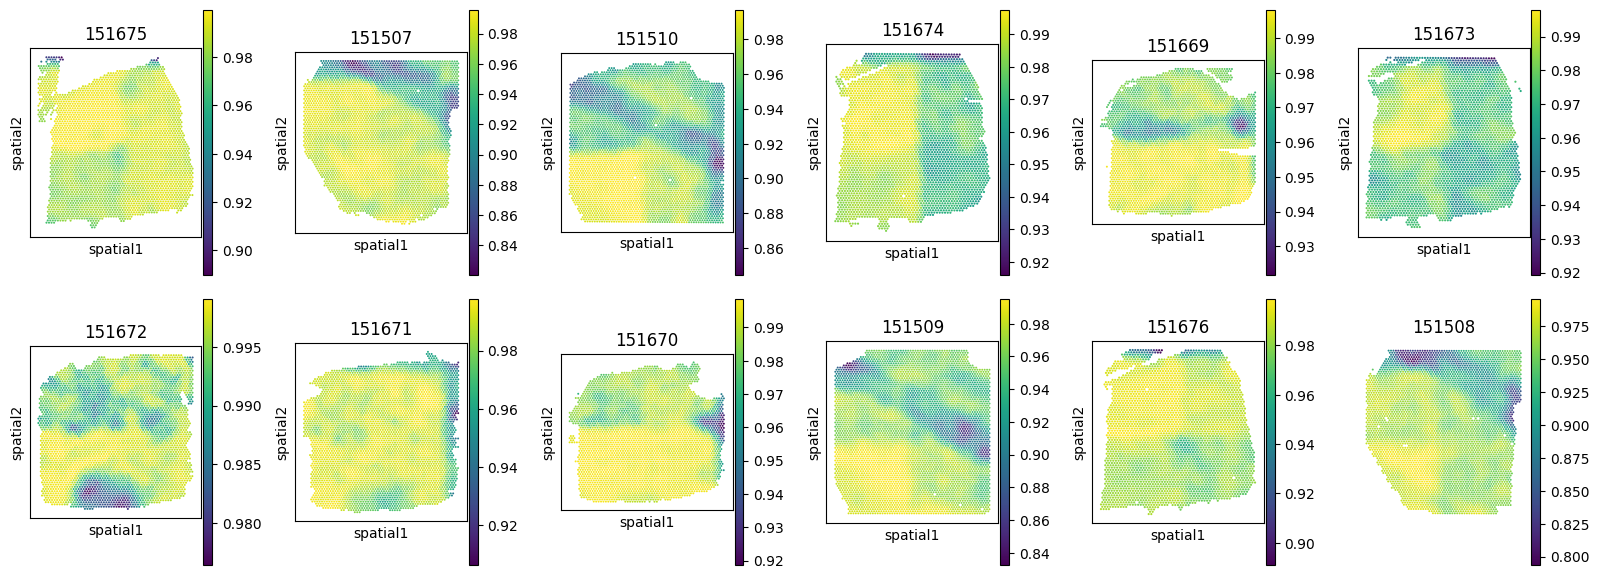

In [11]:
from src.niche_query import NicheQuery
import matplotlib.pyplot as plt

query_result_key = f"{query_niche_id}_query_result"
niche_query = NicheQuery()
adata_list = niche_query.query(
    adata_list, niche_embedding, query_result_key, niche_embedding_key
)

# visualize output
fig, axes = plt.subplots(ncols=6, nrows=2, figsize=(16, 6))
axes = axes.flatten()
for i, adata in enumerate(adata_list):
    sc.pl.spatial(
        adata,
        color=f"{query_result_key}",
        ax=axes[i],
        show=False,
        spot_size=5,
        title=f"{adata.uns['library_id']}",
    )
    axes[i].invert_yaxis()
axes[11].axis("off")
fig.tight_layout()
fig.show()